## Module 4:

## Team Members:
Sara Elster, Lauren Kim

## Project Title:
Evaluating the Effects of Cancer Hallmarks on Tumor Growth and Resilience


## Project Goal:

This project seeks to answer the following questions about the relationships between and effects of cancer hallmarks on tumor growth:

1. Are sustained growth signals related to evasion of growth suppression in lung cancer?
    
    a. Does this trend continue in different cancer types?

2. How does phenotypic plasticity affect treatment response in lung cancer?
    
    a. Does this trend continue in different cancer types?


## Disease Background:

### Cancer Hallmark 1: Sustained Growth Signals
#### Overview of Hallmark
Sustained growth signaling refers to the ability of cancer cells to continuously proliferate without the normal external signals required for cell division by producing their own growth signals (autocrine signaling), overexpressing growth factor receptors, or activating downstream signaling pathways constitutively. This leads to uncontrolled cell division and tumor progression.

#### Genes Associated with Hallmark to be Studied
Key genes involved in sustained growth signaling are typically part of major proliferative pathways such as the RTK/RAS/MAPK and PI3K/AKT/mTOR pathways. Genes of interest include:

* EGFR – encodes a receptor tyrosine kinase that, when overactivated, drives proliferation
* KRAS – a GTPase that transduces growth signals; commonly mutated in cancers
* BRAF – downstream of RAS, activates MAPK signaling
* PIK3CA – catalytic subunit of PI3K, promotes cell growth and survival
* AKT1 – central kinase in survival and growth signaling
* MYC – transcription factor that regulates genes involved in proliferation

**See genes_of_interest.csv for more information on key genes.**

### Cancer Hallmark 2: Evading Growth Suppressors
#### Overview of Hallmark
Evading growth suppressors refers to the ability of cancer cells to bypass mechanisms that inhibit cell proliferation by disabling these tumor suppressor pathways, which normally act as checkpoints to prevent uncontrolled division, repaire DNA damage, and trigger apoptosis. Without these pathways, cancer cells can proliferate despite cellular damage or unfavorable conditions.

#### Genes Associated with Hallmark to be Studied
Key genes involved in evasion of growth suppressors include tumor suppressor genes and cell cycle regulators. Genes of interest include:

* TP53 – encodes p53, a critical regulator of DNA damage response and apoptosis
* RB1 – controls the G1/S checkpoint of the cell cycle
* CDKN2A – encodes p16, an inhibitor of cyclin-dependent kinases
* PTEN – negatively regulates the PI3K/AKT pathway
* SMAD4 – involved in TGF-β signaling, which suppresses proliferation
* APC – regulates β-catenin and Wnt signaling, preventing uncontrolled growth

### Cancer Hallmark 3: Phenotypic Plasticity
#### Overview of Hallmark
Just as the term implies phenotypic plasticity refers to a cancer cell’s ability to transition between various cellular states. Because they lack a definite diffrentiation, this cancer hallmark enables cancerous cells to assume a functionality that more closely aligns with that of a stem cell. Being less differentiated (specialized) allows for other functions such as sustained proliferation and the capacity to take on different phenotypic characteristics. This not only sustains the cancer cell but also allows them to become more adaptable to various environments via metabolic reprogramming and epthelial-mesenchymal transition. When working in concert with one another, these enabled functions give tumours power to resist treatment or therapies designed to combat cancerous cells. 

#### Genes Associated with Hallmark to be Studied
Key genes involved in phenotypic plasticity are typically part of cellular pathways such as epithelial-mesenchymal transition (EMT). 

Genes of interest include:
* Twist - regulates gene expression related to epithelial and mesenchymal features. 
* Snail - regulates gene expression related to epithelial and mesenchymal features. 
* Slug - regulates gene expression related to epithelial and mesenchymal features. 
* ZEB1 - regulates gene expression related to epithelial and mesenchymal features. 

**See genes_of_interest.csv for more information on key genes.**



### Cancer Types
#### Lung Adenocarcinoma
**Prevalence & incidence**

The World Health Organization reports ~2.2 million new cases and 1.8 million deaths globally per year. In the U.S., the American Cancer Society estimates ~238,000 new cases annually.

**Risk Factors**
* Lifestyle: Smoking
* Environmental: Radon, air pollution, asbestos
* Genetic: Mutations, family history
* Societal: Lower socioeconomic status, limited screening access, healthcare disparities

**Standard of Care Treatments**
* Surgery
* Radiation & chemotherapy
* Targeted therapy
* Immunotherapy

**Biological Mechanism**

Lung cancer is caused by uncontrolled cell growth in lung tissue. Mutations in oncogenes (EGFR, KRAS) drive proliferation, and loss of tumor suppressors (TP53) removes growth control, which leads to tumor formation, invasion, and metastasis.

## Data-Set: 

The raw dataset was provided by Dr. Groves and was entitled, "TRAINING_SET_GSE62944_subsample_log2TPM.csv". Of the raw data, we elected to focus on Lung Adenocarcinoma and filter the dataset for genes of interest related to the hallmarks of sustained growth signals, evading growht suppressors, and phenotypic plascticity. 

In [1]:
# Exploratory data analysis (EDA) on a cancer dataset
# Loading the files and exploring the data with pandas
# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# %%
# Load the data
####################################################
data = pd.read_csv(
    '../Data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)  # can also use larger dataset with more genes
metadata_df = pd.read_csv(
    '../Data/TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)
print(data.head())

        TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
A1BG                        3.397369                      3.466089   
A1CF                        0.008857                      0.039562   
A2M                         7.575125                      6.643613   
A2ML1                       0.397610                      7.625124   
A4GALT                      5.277425                      5.244677   

        TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
A1BG                        3.789771                      3.967578   
A1CF                        0.065051                      0.000000   
A2M                         9.024479                      7.573842   
A2ML1                       0.428689                      0.465410   
A4GALT                      4.072650                      4.208381   

        TCGA-LL-A5YN-01A-11R-A28M-07  TCGA-BH-A0DQ-01A-11R-A084-07  \
A1BG                        4.733007                      3.011343   
A1CF              

## Data Analysis: 



### 1. After loading the raw dataset as described above, the data was filtered to append only LUAD data to a list. 

In [2]:
cancer_type = 'LUAD'  # Lung Adenocarcinoma

# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
print(cancer_samples)
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
LUAD_data = data[cancer_samples]

# %%
# Subset by index (genes)
####################################################
desired_gene_list = ['TP53', 'BRAF', 'KRAS', 'EGFR', 'MYC','PIK3CA','AKT1', 'RB1', 'CDKN2A', 'PTEN','SMAD4','APC','ZEB1']
gene_list = [gene for gene in desired_gene_list if gene in LUAD_data.index]
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")

# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
LUAD_gene_data = LUAD_data.loc[gene_list]
print(LUAD_gene_data.head())

Index(['TCGA-44-8117-01A-11R-2241-07', 'TCGA-50-5936-01A-11R-1628-07',
       'TCGA-55-A494-01A-11R-A24X-07', 'TCGA-78-7160-01A-11R-2039-07',
       'TCGA-78-7158-01A-11R-2039-07', 'TCGA-78-7149-01A-11R-2039-07',
       'TCGA-64-5775-01A-01R-1628-07', 'TCGA-78-7147-01A-11R-2039-07',
       'TCGA-44-6777-01A-11R-1858-07', 'TCGA-49-4490-01A-21R-1858-07',
       'TCGA-NJ-A4YF-01A-12R-A262-07', 'TCGA-44-5643-01A-01R-1628-07',
       'TCGA-86-8674-01A-21R-2403-07', 'TCGA-99-8033-01A-11R-2241-07',
       'TCGA-91-8497-01A-11R-2403-07', 'TCGA-86-7711-01A-11R-2066-07',
       'TCGA-55-7724-01A-11R-2170-07', 'TCGA-67-3774-01A-01R-0946-07',
       'TCGA-67-3773-01A-01R-0946-07', 'TCGA-50-8460-01A-11R-2326-07',
       'TCGA-44-6146-01A-11R-1755-07', 'TCGA-86-8280-01A-11R-2287-07',
       'TCGA-55-8615-01A-11R-2403-07', 'TCGA-50-5930-01A-11R-1755-07',
       'TCGA-44-2662-01A-01R-A278-07', 'TCGA-62-A46V-01A-11R-A24H-07',
       'TCGA-55-7281-01A-11R-2039-07', 'TCGA-44-5644-01A-21R-2039-07',
      

### 2. The subsequent step was to filter the newly formed LUAD dataset for the specified genes of interest (selcetion criteria was based on gene association with the hallmarks of sustained growth factors, evading growth suppression, and phenotypic plasticity)

In [3]:
desired_gene_list = ['TP53', 'BRAF', 'KRAS', 'EGFR', 'MYC','PIK3CA','AKT1', 'RB1', 'CDKN2A', 'PTEN','SMAD4','APC','ZEB1']
gene_list = [gene for gene in desired_gene_list if gene in LUAD_data.index]
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")

# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
LUAD_gene_data = LUAD_data.loc[gene_list]
print(LUAD_gene_data.head())

      TCGA-44-8117-01A-11R-2241-07  TCGA-50-5936-01A-11R-1628-07  \
TP53                      3.533095                      5.960825   
BRAF                      3.107750                      2.322553   
KRAS                      5.564254                      5.501215   
EGFR                      5.948056                      4.908641   
MYC                       5.406649                      6.577189   

      TCGA-55-A494-01A-11R-A24X-07  TCGA-78-7160-01A-11R-2039-07  \
TP53                      6.236896                      6.803066   
BRAF                      2.956489                      2.371141   
KRAS                      6.517595                      5.480804   
EGFR                      5.058511                      3.980713   
MYC                       6.340323                      6.659490   

      TCGA-78-7158-01A-11R-2039-07  TCGA-78-7149-01A-11R-2039-07  \
TP53                      7.446952                      6.262349   
BRAF                      3.133800            

### 3. The next step was to analyze the newly filtered dataset for statistical variance across mean and median expression values. 

In [4]:
print(LUAD_gene_data.describe())
print(LUAD_gene_data.var(axis=1))  # Variance of each gene across samples
# Mean expression of each gene across samples
print(LUAD_gene_data.mean(axis=1))
# Median expression of each gene across samples
print(LUAD_gene_data.median(axis=1))

       TCGA-44-8117-01A-11R-2241-07  TCGA-50-5936-01A-11R-1628-07  \
count                     13.000000                     13.000000   
mean                       4.488728                      4.819492   
std                        1.373620                      1.310026   
min                        2.970138                      2.322553   
25%                        3.497082                      4.147990   
50%                        4.591766                      4.908641   
75%                        5.406649                      5.501215   
max                        7.569248                      7.029184   

       TCGA-55-A494-01A-11R-A24X-07  TCGA-78-7160-01A-11R-2039-07  \
count                     13.000000                     13.000000   
mean                       4.485765                      4.809095   
std                        1.740030                      1.572109   
min                        2.148525                      2.371141   
25%                        3.0023

### 4. The next step was to explore the dataset within a certain category (which was gender) and then within the subcategory of gender, filter and calculate the mean age at diagnosis. 

In [5]:
#explore dataset by gender
print(metadata_df.groupby('cancer_type')["gender"].value_counts())

# Explore average age at diagnosis by cancer type
metadata_df['age_at_diagnosis'] = pd.to_numeric(
    metadata_df['age_at_diagnosis'], errors='coerce')
print(metadata_df.groupby(
    'cancer_type')["age_at_diagnosis"].mean())
# %%
# Merging datasets
####################################################
# Merge the subsetted expression data with metadata for BRCA samples,
# so rows are samples and columns include gene expression for EGFR and MYC and metadata
LUAD_metadata = metadata_df.loc[cancer_samples]
LUAD_merged = LUAD_gene_data.T.merge(
    LUAD_metadata, left_index=True, right_index=True)
print(LUAD_merged.head())

cancer_type  gender
ACC          FEMALE    48
             MALE      31
BLCA         MALE      66
             FEMALE    10
BRCA         FEMALE    74
             MALE       2
CESC         FEMALE    77
COAD         MALE      41
             FEMALE    31
GBM          MALE      49
             FEMALE    21
HNSC         MALE      58
             FEMALE    19
KICH         MALE      39
             FEMALE    27
KIRC         MALE      51
             FEMALE    27
KIRP         MALE      49
             FEMALE    24
LAML         MALE      45
             FEMALE    35
LGG          MALE      40
             FEMALE    30
LIHC         MALE      56
             FEMALE    21
LUAD         FEMALE    39
             MALE      35
LUSC         MALE      54
             FEMALE    24
OV           FEMALE    77
PRAD         MALE      78
READ         MALE      44
             FEMALE    36
SKCM         MALE      50
             FEMALE    29
STAD         MALE      50
             FEMALE    30
THCA         FEMAL

### 5. Finally, stasticial analysis was added onto the merged dataset for gene expression in LUAD samples by gender. Box plots were used to show statistical variance between groups. 

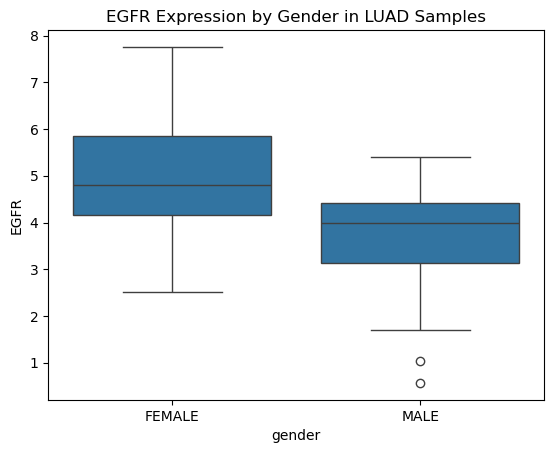

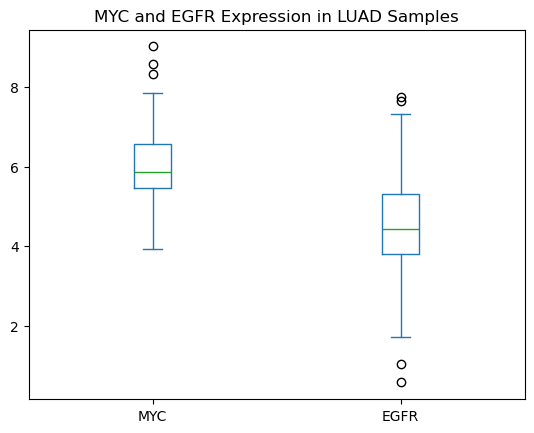

In [6]:
sns.boxplot(data=LUAD_merged, x="gender", y='EGFR')
plt.title("EGFR Expression by Gender in LUAD Samples")
plt.show()

# Boxplot of MYC and EGFR expression in LUAD samples using PANDAS directly
LUAD_merged[['MYC', 'EGFR']].plot.box()
plt.title("MYC and EGFR Expression in LUAD Samples")
plt.show()

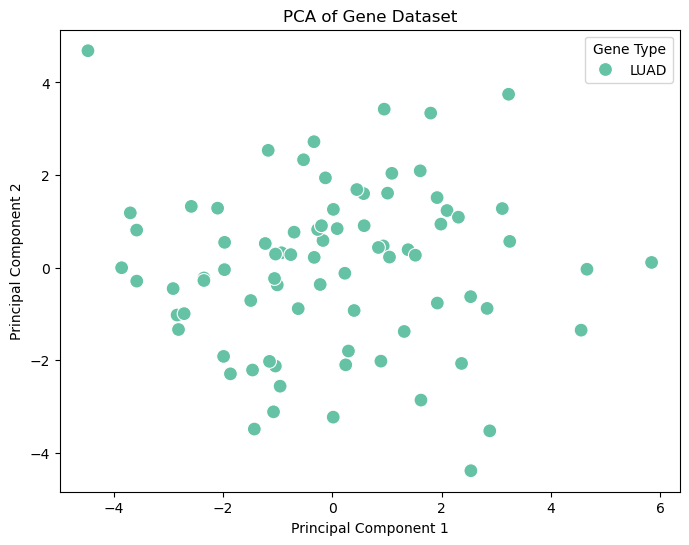

In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.decomposition import PCA

X = LUAD_gene_data.T

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0],
                y=X_pca[:, 1],
                hue = LUAD_merged['cancer_type'],
        
        
                palette="Set2",
                s=100)
plt.title("PCA of Gene Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Gene Type")
plt.show()


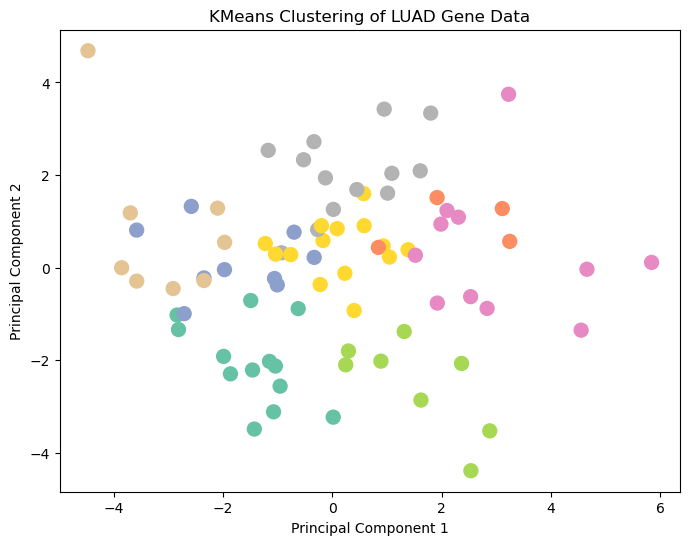

In [18]:
# KMeans Clustering

model = KMeans(random_state=0)
model.fit(X)
y_kmeans = model.predict(X)
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap="Set2", s=100)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clustering of LUAD Gene Data")

plt.show()

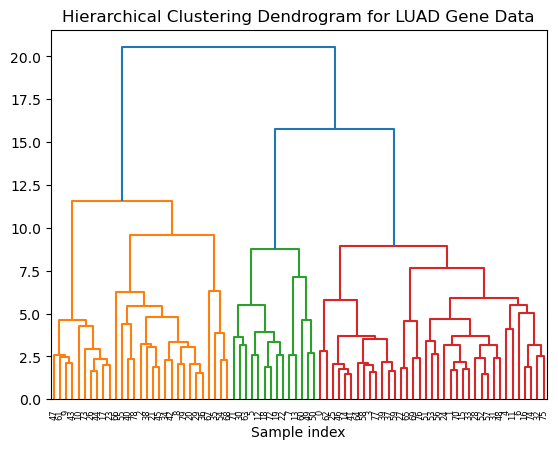

In [19]:
# Hierarchical Clustering

import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X)
plt.title("Hierarchical Clustering Dendrogram for LUAD Gene Data")
# plot the top three levels of the dendrogram
plot_dendrogram(model)
plt.xlabel("Sample index")
plt.show()

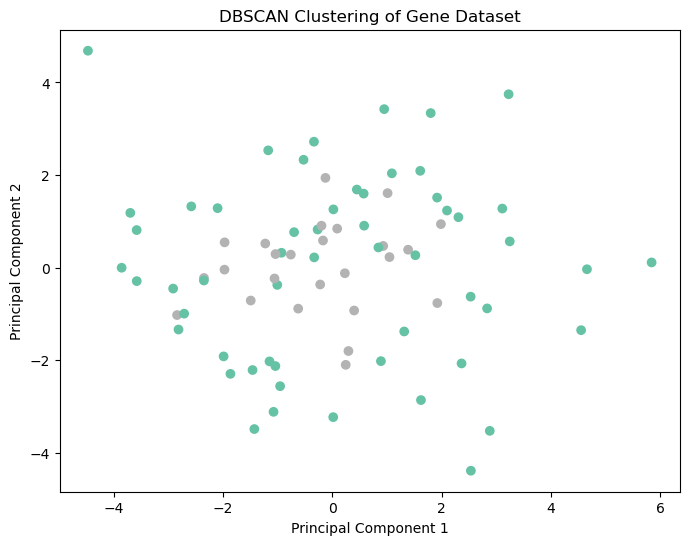

In [8]:
# use DBSCAN to cluster the gene data
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps= 2, min_samples=5)
y_dbscan = dbscan.fit_predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_dbscan, cmap="Set2")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering of Gene Dataset")
plt.show()

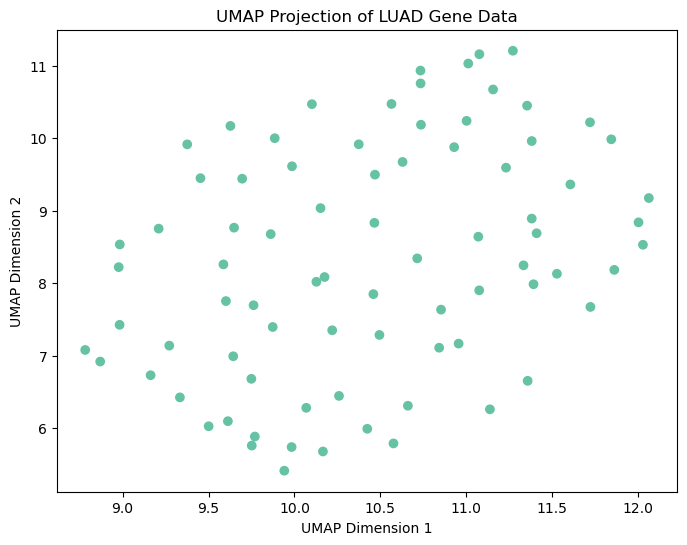

In [21]:
from sklearn.preprocessing import StandardScaler
import umap

scaled_data = StandardScaler().fit_transform(X)

reducer = umap.UMAP()
X_umap = reducer.fit_transform(scaled_data)
y_dbscan = dbscan.fit_predict(X_umap)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_dbscan, cmap="Set2")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of LUAD Gene Data")
plt.show()

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*

## Citations

https://doi.org/10.1016/j.semcancer.2015.02.006

https://doi.org/10.1016/j.cell.2011.02.013

https://www.ncbi.nlm.nih.gov/books/NBK519578/